# 🏥 EgoExOR Dataset Tutorial

> **NeurIPS 2025 Datasets & Benchmarks** · *First OR dataset to fuse egocentric + exocentric perspectives*

**EgoExOR** unifies first-person (surgeon's view) and third-person (room context) in one place. This tutorial walks you through exploring it.

## ⚡ Dataset at a glance

- **~94 minutes** of emulated spine surgery (84,553 frames at 15 FPS)
- **Two procedures**: Ultrasound-Guided Needle Insertion, Minimally Invasive Spine Surgery (MISS)
- **Egocentric**: RGB, gaze, hand tracking, audio from wearable glasses
- **Exocentric**: RGB-D, ultrasound, fixed cameras
- **Scene graphs**: 36 entities, 22 relations → **568K triplets**

**Why it matters**: Fused ego–exo at same timestamp · Rich clinical annotations · Built for surgical AI


## 1. Dataset versions

| Version | Storage | Notes |
|---------|---------|-------|
| **Legacy** (v1) | Hugging Face `ardamamur/EgoExOR` | LUT applied externally for Azure Kinect |
| **HQ** (EgoExOR-HQ) | Hugging Face `TUM/EgoExOR` | Higher resolution (1344×1344), raw depth images, per-device audios, RGB pre-corrected |

Both use the same params: **procedure**, **phase**, **take**.


## 2. Setup — Load your HDF5 file

Set `dataset_version`, path, and the take to explore. Use `list_available_takes(f_path)` to discover (procedure, phase, take) if unsure.


In [ ]:
# Choose: "legacy" (EgoExOR v1) or "hq" (EgoExOR-HQ)
dataset_version = "hq"

# Same param names for both: procedure, phase, take
procedure, phase, take = "MISS", 4, 2

if dataset_version == "legacy":
    from utils.load_h5 import load_egoexor_h5
    f_path = Path("path/to/your/local/EgoExOR/miss_4.h5")
    #f_path = load_egoexor_h5("ardamamur/EgoExOR", "miss_4.h5")
else:
    from pathlib import Path
    f_path = Path("path/to/your/local/EgoExOR-HQ/miss_4.h5")
    # f_path = load_egoexor_h5("TUM/EgoExOR", "miss_4.h5")

kw = {"procedure": procedure, "phase": phase, "take": take}


## 3. Explore available takes

List all (procedure, phase, take) in the file.


In [5]:
from utils.load_h5 import list_available_takes
takes = list_available_takes(f_path)
print(f"This file contains {len(takes)} take(s):")
for t in takes:
    print(f"  {t}")


This file contains 2 take(s):
  ('MISS', 4, 1)
  ('MISS', 4, 2)


## 4. Inspect take metadata

Resolution, frame count, cameras, and modalities for the selected take.


In [6]:
import h5py
from utils.load_h5 import detect_dataset_version, get_take_path

version = detect_dataset_version(f_path)
take_path = get_take_path(version, procedure=procedure, phase=phase, take=take)

with h5py.File(f_path, "r") as f:
    rgb = f[f"{take_path}/frames/rgb"]
    n_frames, n_cams, h, w, _ = rgb.shape
    src = f[f"{take_path}/sources"]
    cam_names = []
    for i in range(src.attrs["source_count"]):
        name = src.attrs.get(f"source_{i}", f"cam_{i}")
        cam_names.append(name.decode() if isinstance(name, bytes) else str(name))

print(f"Take: {take_path}")
print(f"  Frames: {n_frames} ({n_frames/15:.1f} sec @ 15 FPS)")
print(f"  Resolution: {h}×{w}")
print(f"  Cameras ({n_cams}): {cam_names}")


Take: procedures/MISS/phases/4/takes/2
  Frames: 995 (66.3 sec @ 15 FPS)
  Resolution: 1344×1344
  Cameras (10): ['assistant', 'head_surgeon', 'circulator', 'anesthetist', 'microscope', 'external_1', 'external_2', 'external_3', 'external_4', 'external_5']


### 📚 Entity & relation vocabulary (from HDF5 metadata)


In [7]:
import h5py
with h5py.File(f_path, "r") as f:
    if "/metadata/vocabulary/entity" in f:
        ents = [e[0].decode() if isinstance(e[0], bytes) else str(e[0]) for e in f["/metadata/vocabulary/entity"][:]]
        print(f"🟢 Entities ({len(ents)}):", ", ".join(ents[:10]) + "...")
    if "/metadata/vocabulary/relation" in f:
        rels = [r[0].decode() if isinstance(r[0], bytes) else str(r[0]) for r in f["/metadata/vocabulary/relation"][:]]
        print(f"🔗 Relations ({len(rels)}):", ", ".join(rels))


🟢 Entities (37): anaesthetist, anesthesia_equipment, antiseptic, assistant, bin, body_marker, circulator, cotton, curette, dressing_material...
🔗 Relations (23): anesthasing, applying, aspirating, checking, closeTo, controlling, cutting, disinfection, dressing, dropping, entering, holding, injecting, inserting, looking, lyingOn, manipulating, positioning, preparing, removing, scanning, touching, wearing


## 5. Camera roles

- **Egocentric**: `head_surgeon`, `assistant`, `circulator`, `anesthetist` — first-person with gaze + hand tracking
- **Exocentric**: `or_light`, `microscope`, `external_1`-`5`, `simstation`, `ultrasound` — third-person views


## 6. Visualize a single frame

Mosaic of all cameras at one timestamp. Gaze (blue) and hand points overlaid on egocentric views.



📊 Scene Graph Annotation 📊

· patient lyingOn operating_table
· head_surgeon closeTo operating_table
· anaesthetist closeTo operating_table
· assistant closeTo operating_table
· head_surgeon holding dressing_material
· assistant looking instrument_table
· head_surgeon dressing patient
· dressing_material touching patient


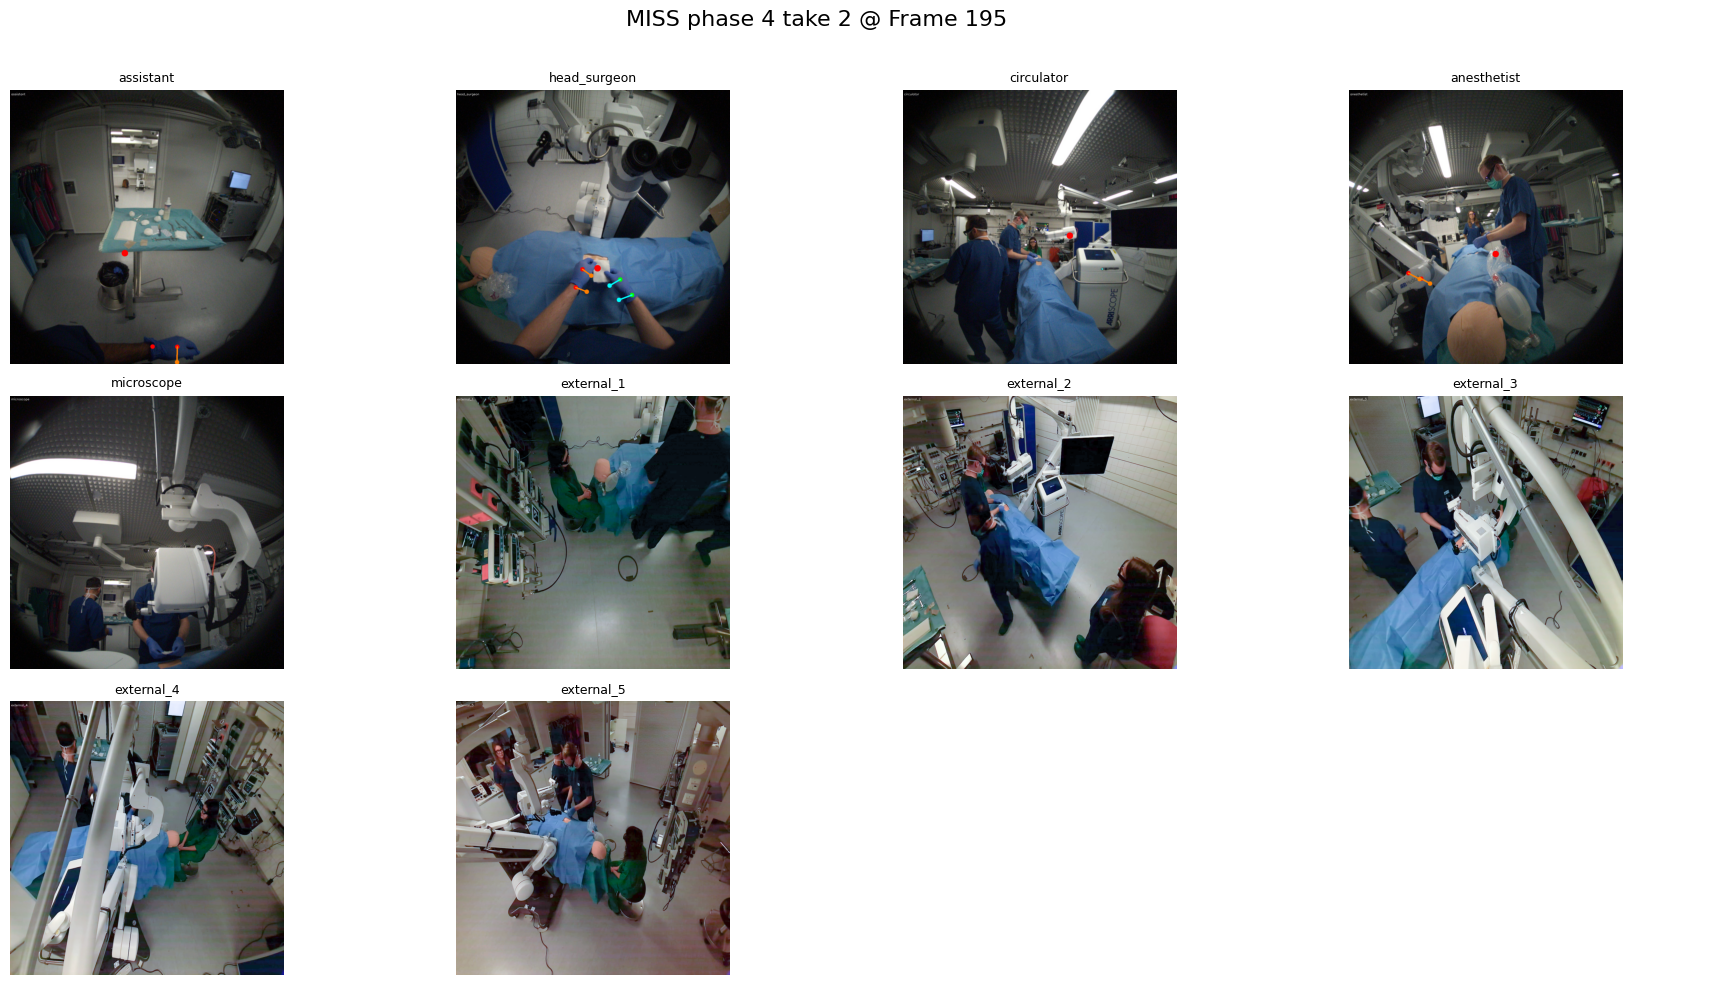

In [2]:
from utils.visualize_timepoint import visualize_frame_group
visualize_frame_group(
    h5_path=f_path,
    frame_idx=195,
    save_frames=False,
    **kw,
)


## 7. Generate video

Render the take as a mosaic video. For HQ, frames are resized to 336×336.


In [3]:
from utils.visualize_take import visualize_take
visualize_take(
    h5_file=f_path,
    output_path="miss_4_2.mp4",
    include_audio=False,
    debug_limit=45,
    **kw,
)


Processing frames: 100%|██████████| 45/45 [00:06<00:00,  7.42it/s]


Video saved to 'temp_noaudio_MISS_4_2.mp4'.


---

## 📎 Quick reference & resources

| Task | Code |
|------|------|
| Single frame | `visualize_frame_group(h5_path=..., procedure=..., phase=..., take=..., frame_idx=...)` |
| Video | `visualize_take(h5_file=..., output_path=..., procedure=..., phase=..., take=...)` |

**Links**: [Paper (arXiv)](https://arxiv.org/abs/2505.24287) · [Hugging Face Legacy](https://huggingface.co/datasets/ardamamur/EgoExOR) · [Hugging Face HQ](https://huggingface.co/datasets/TUM/EgoExOR) · [GitHub](https://github.com/egeozsoy/EgoExOR)
